# Netflix Password Crackdown — a quantitative teardown 🔬
### A market-model event study on 5 public dates · per-event CARs · a 4,000-draw random-calendar placebo · a leave-one-out robustness cut · a costed long-only timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Upside surprise%3F: 1 of 5 events](https://img.shields.io/badge/Upside_surprise%3F-1_of_5_events-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — Netflix's 2023 paid-sharing ("password crackdown"), feared to spike churn, became an upside surprise — is a real corporate turnaround. The job here is to test whether it shows up as a **tradable abnormal-return signal** around its five public dates, and to be explicit that **N = 5 → almost no power** (this is a case study).

> ⚠️ **Data note.** NFLX + SPY + QQQ total-return closes (2015→2026-06-30), yfinance, cached; **5 hardcoded public crackdown dates** 2022→2023 (Netflix letters/newsroom). Market model: OLS α/β on a 120-session estimation window ending 10 sessions before the event window; event window [−1..+5]; earnings react next session (one documented lag). Numbers in [`docs/results.md`](../docs/results.md) (fingerprints `5fff2e717a0c` NFLX / `da459bd64b22` SPY / `f8f1d5c5542a` QQQ).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nflx_crackdown import data, strategy as st

EVENTS = data.event_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    R_N = st.daily_returns(PX["NFLX"]); R_S = st.daily_returns(PX["SPY"]); R_Q = st.daily_returns(PX["QQQ"])
else:
    PX = R_N = R_S = R_Q = None
print("real cache present:", HAVE_REAL, "| crackdown dates in table:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 5, 'cal_lo': '2022-04-20', 'cal_hi': '2023-10-19', 'ev': {'2022-04-20': (-34.55, 1.6, "Q1'22 letter first flags paid-sharing (sub miss)"), '2022-08-22': (-2.34, 1.66, "LatAm 'add-a-home' test"), '2023-05-23': (-0.34, 1.5, 'broad US rollout'), '2023-07-20': (-7.64, 1.37, "Q2'23 +5.9M subs (rev miss)"), '2023-10-19': (17.34, 1.55, "Q3'23 +8.8M subs — the payoff")}, 'day0_mean_pct': -5.51, 'day0_t': -0.657, 'hit': 1, 'hit_n': 5, 'wilson': (4.0, 62.0), 'boot_lo': -21.7, 'boot_hi': 8.4, 'wincar_mean_pct': -4.01, 'wincar_t': -0.383, 'postcar_mean_pct': 1.39, 'postcar_t': 0.447, 'qqq_day0_mean_pct': -4.79, 'qqq_day0_t': -0.594, 'placebo_mean_pct': -0.01, 'placebo_sd_pct': 1.07, 'placebo_p_right': 0.998, 'placebo_p_left': 0.003, 'placebo_draws': 4000, 'drop_crash_mean_pct': 1.75, 'drop_crash_t': 0.324, 'drop_crash_n': 4, 'conf_mean_pct': 4.85, 'conf_t': 0.388, 'conf_n': 2, 'timer': {1: (-87.7, -107.7, -1.06, 20, 12.9), 3: (65.4, 45.4, 0.19, 60, 39.6), 5: (-231.9, -251.9, -0.56, 40, 66.6), 10: (62.7, 42.7, 0.11, 40, 134.0), 21: (264.7, 244.7, 0.34, 60, 277.0)}, 'syn_null_mean_t': 0.37, 'syn_null_sd_t': 1.06, 'syn_null_fire': 1, 'syn_planted_pct': 2.86, 'syn_planted_t': 11.12, 'fp_nflx': '5fff2e717a0c', 'fp_spy': 'da459bd64b22', 'fp_qqq': 'f8f1d5c5542a'}


real cache present: True | crackdown dates in table: 5


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | cross-event mean day-0 abnormal return **-5.51%**, one-sample **t = -0.66** (n=5), up-days 1/5 (Wilson [4%, 62%]) |
| **Tradability** | `MIRAGE` | buy-the-event never reliably beats holding NFLX; net *t* ∈ [-1.06, 0.34] across 1/3/5/10/21-day holds |
| **Upside surprise?** | `1 of 5` | only Q3'23 (**+17%** abnormal) delivered; the mean is dragged negative by the **-35%** 2022 flag crash |

> 💡 In plain words: a genuine business turnaround, but the five-event stock reaction is one crash + one pop + three shrugs — no power, no tradable edge.

## 1 · The claim, steelmanned

Let $r_t$ be NFLX's daily return and $r^m_t$ the benchmark's. Under a one-factor market model fit on an estimation window, the *normal* return is $\hat\alpha + \hat\beta r^m_t$ and the **abnormal** return is $a_t = r_t - (\hat\alpha + \hat\beta r^m_t)$. For each crackdown event $i$ with reaction session $\tau_i$:

- **H₁ (upside surprise).** $E[a_{\tau_i}] > 0$, systematically across events.
- **H₂ (drift).** The post-event CAR $\sum_{k=1}^{5} a_{\tau_i+k}$ is positive (a re-rating that keeps paying).
- **H₃ (capture).** A long-NFLX-after-the-event overlay beats unconditional buy-and-hold net of costs.

We find **H₁ not supported** (mean -5.51%, t = -0.66 — *negative*, driven by one outlier), **H₂ not supported** (post-CAR +1.39%, t = 0.45), **H₃ not supported** (no horizon beats hold). The honest headline is **low power**, not a discovered anti-signal.

## 2 · So what? — inference design

The five events are **independent, non-overlapping calendar dates**, so the planned primary is a **one-sample t** across the per-event abnormal returns — but with **4 degrees of freedom** that t has famously fat tails (the |t|≥2 rule of thumb corresponds to p≈0.12 here, not 0.05), which is exactly why we lean on a **non-parametric random-calendar placebo** (4,000 draws of 5 random dates) and an **event-bootstrap CI** instead of trusting the t alone. A **leave-one-out** cut isolates how completely the 2022 crash drives the result. The **synthetic control** is run on **30** pseudo-events precisely so the machinery's calibration can be judged free of the small-N fat tails.

## 3 · How we'd know — the protocol

- **Calendar.** 5 public dates 2022-04-20 → 2023-10-19, hardcoded (earnings react next session — one documented lag).
- **Tape.** NFLX + SPY + QQQ total-return closes, 2015 → 2026-06-30 (as-of, last complete month).
- **Abnormal return.** Market model, OLS α/β on 120 sessions ending 10 sessions before the event window (strictly out-of-sample); SPY headline, QQQ cross-check.
- **Headline.** Cross-event mean day-0 AR + one-sample t + Wilson hit rate + event-bootstrap CI.
- **Anatomy.** CAR path [−1..+5]; whole-window and post-event CARs.
- **Placebo.** 4,000 random 5-date calendars, both tails.
- **Robustness.** Drop the 2022-04 crash; confirmation-earnings-only subset.
- **Timer.** Long NFLX from the event close, hold 1/3/5/10/21 sessions, one round trip of one-way cost ×2, vs unconditional NFLX baseline.
- **Control.** Synthetic one-factor tape, planted one-day jump on 30 pseudo-events; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · Per-event abnormal returns and the CAR path

The event window [−1..+5] abnormal-return path (SPY market model), and each event's own day-0 abnormal return.

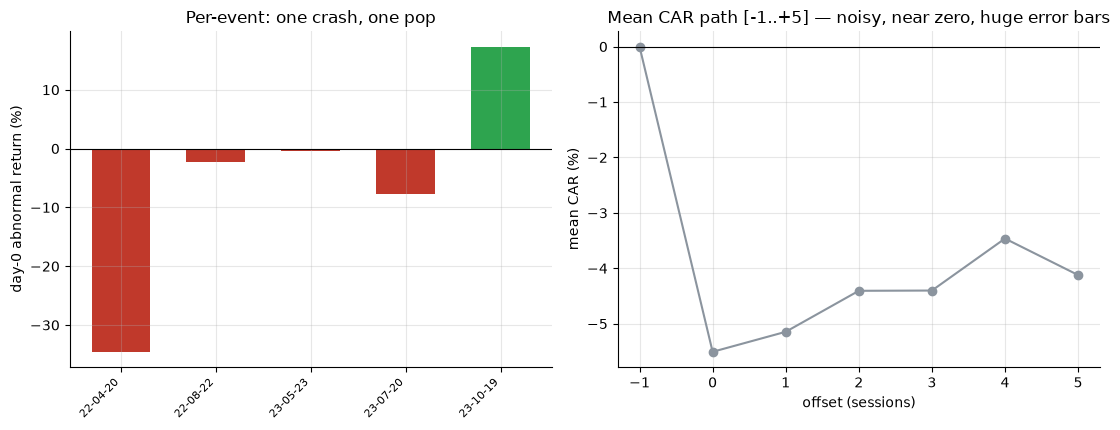

day-0 abnormal (%): [np.float64(-34.6), np.float64(-2.3), np.float64(-0.3), np.float64(-7.6), np.float64(17.3)]
whole-window CAR -4.01% (t=-0.38); post-event CAR +1.39% (t=0.45)


In [2]:
if HAVE_REAL:
    cp = st.car_path_stats(R_N, R_S, EVENTS['date'], pre=1, post=5, model='market')
    ks = list(cp.index); car = list(cp['car'] * 100)
    mat, kept, betas = st.event_car(R_N, R_S, EVENTS['date'], pre=1, post=5, model='market')
    ev_vals = [row[1] * 100 for row in mat]
    ev_lab = [d.strftime('%y-%m-%d') for d in kept]
else:
    ks = list(range(-1, 6)); car = None
    ev_lab = [k[2:] for k in R['ev']]; ev_vals = [R['ev'][k][0] for k in R['ev']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
cols = [GREEN if v > 0 else RED for v in ev_vals]
a1.bar(range(len(ev_vals)), ev_vals, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_xticks(range(len(ev_vals)))
a1.set_xticklabels(ev_lab, rotation=45, fontsize=8, ha='right')
a1.set_ylabel('day-0 abnormal return (%)')
a1.set_title('Per-event: one crash, one pop')
if car is not None:
    a2.plot(ks, car, marker='o', color=GREY)
    a2.axhline(0, c='k', lw=.8); a2.set_xlabel('offset (sessions)')
    a2.set_ylabel('mean CAR (%)')
    a2.set_title('Mean CAR path [-1..+5] — noisy, near zero, huge error bars')
plt.tight_layout(); plt.show()
print('day-0 abnormal (%):', [round(v,1) for v in ev_vals])
print(f"whole-window CAR {R['wincar_mean_pct']:+.2f}% (t={R['wincar_t']:.2f}); "
      f"post-event CAR {R['postcar_mean_pct']:+.2f}% (t={R['postcar_t']:.2f})")

> 💡 In plain words: the CAR path is a wandering line near zero — the whole-window CAR is **-4.01%** (t = -0.38) and the post-event drift **+1.39%** (t = 0.45). Nothing here clears the bar; the two big bars (2022 crash, 2023 pop) sit on opposite sides and cancel.

### 4b · The headline mean and its random-calendar placebo

Cross-event mean day-0 AR vs 4,000 random 5-date calendars. In the notebook we run a lighter placebo and quote the canonical 4,000-draw p from `results.md`.

mean -5.51%  t = -0.66  bootstrap 95% CI [-21.7%, +8.4%]


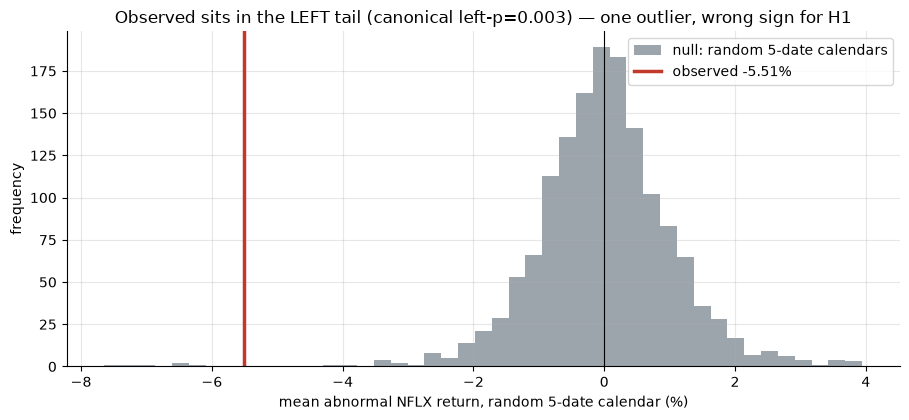

canonical placebo: mean -0.01% (sd 1.07%), left-p 0.003, right-p 0.998; Wilson hit [4%,62%]


In [3]:
if HAVE_REAL:
    d0 = st.day0_stats(R_N, R_S, EVENTS['date'], model='market')
    obs = d0['mean']
    blo, bhi = st.block_bootstrap_ci(d0['per_event'], n_boot=4000, seed=851)
    pl = st.placebo_distribution(R_N, R_S, d0['n'], model='market', n_draws=1500, seed=851)
    draws = pl * 100
    print(f"mean {d0['mean']*100:+.2f}%  t = {d0['t']:+.2f}  "
          f"bootstrap 95% CI [{blo*100:+.1f}%, {bhi*100:+.1f}%]")
else:
    obs = R['day0_mean_pct'] / 100
    rng = np.random.default_rng(851)
    draws = rng.normal(R['placebo_mean_pct'], R['placebo_sd_pct'], 1500)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label='null: random 5-date calendars')
ax.axvline(obs * 100, c=RED, lw=2.5, label=f'observed {obs*100:+.2f}%')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('mean abnormal NFLX return, random 5-date calendar (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Observed sits in the LEFT tail (canonical left-p={R['placebo_p_left']:.3f}) — one outlier, wrong sign for H1")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo: mean {R['placebo_mean_pct']:+.2f}% (sd {R['placebo_sd_pct']:.2f}%), "
      f"left-p {R['placebo_p_left']:.3f}, right-p {R['placebo_p_right']:.3f}; "
      f"Wilson hit [{R['wilson'][0]:.0f}%,{R['wilson'][1]:.0f}%]")

> 💡 In plain words: the observed **-5.51%** is more *negative* than 99.7% of random five-date calendars (left-p = 0.003) — but that is the **2022 crash outlier** talking, not a downside edge. The event-bootstrap CI **[-21.7%, +8.4%]** straddles zero by a mile. H₁ (a positive upside surprise) is not supported; neither is any robust negative.

### 4c · Robustness — the whole result is one date

Leave-one-out on the 2022-04 announcement crash, and a confirmation-earnings-only subset.

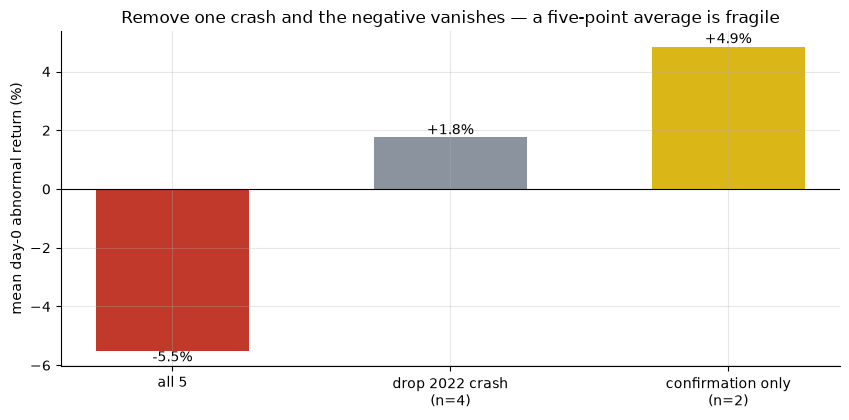

drop-crash (n=4): +1.75% (t=+0.32);  confirmation-only (n=2): +4.85% (t=+0.39)


In [4]:
if HAVE_REAL:
    sub = EVENTS.loc[EVENTS['date'] != '2022-04-20', 'date']
    d0s = st.day0_stats(R_N, R_S, sub, model='market')
    conf = EVENTS.loc[EVENTS['date'].isin(pd.to_datetime(['2023-07-20','2023-10-19'])), 'date']
    d0c = st.day0_stats(R_N, R_S, conf, model='market')
    drop_m, drop_t = d0s['mean']*100, d0s['t']
    conf_m, conf_t = d0c['mean']*100, d0c['t']
else:
    drop_m, drop_t = R['drop_crash_mean_pct'], R['drop_crash_t']
    conf_m, conf_t = R['conf_mean_pct'], R['conf_t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['all 5', 'drop 2022 crash\n(n=4)', 'confirmation only\n(n=2)'],
       [R['day0_mean_pct'], drop_m, conf_m], color=[RED, GREY, AMBER], width=.55)
for i, v in enumerate([R['day0_mean_pct'], drop_m, conf_m]):
    ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom' if v>0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean day-0 abnormal return (%)')
ax.set_title('Remove one crash and the negative vanishes — a five-point average is fragile')
plt.tight_layout(); plt.show()
print(f'drop-crash (n=4): {drop_m:+.2f}% (t={drop_t:+.2f});  '
      f'confirmation-only (n=2): {conf_m:+.2f}% (t={conf_t:+.2f})')

> 💡 In plain words: drop the single 2022-04 crash and the mean flips to **+1.75%** (t = 0.32) — essentially zero. The confirmation earnings alone (Q2+Q3'23) average **+4.85%** (t = 0.39), positive but utterly powerless on n=2. Every cut says the same thing: too few events.

### 4d · The timer — an honest "buy the event" cost sweep

Enter NFLX at the event-session close (zero look-ahead — the after-close print is already public), hold `h` sessions, one round trip of one-way costs charged twice, long-only, vs the unconditional NFLX `h`-day baseline.

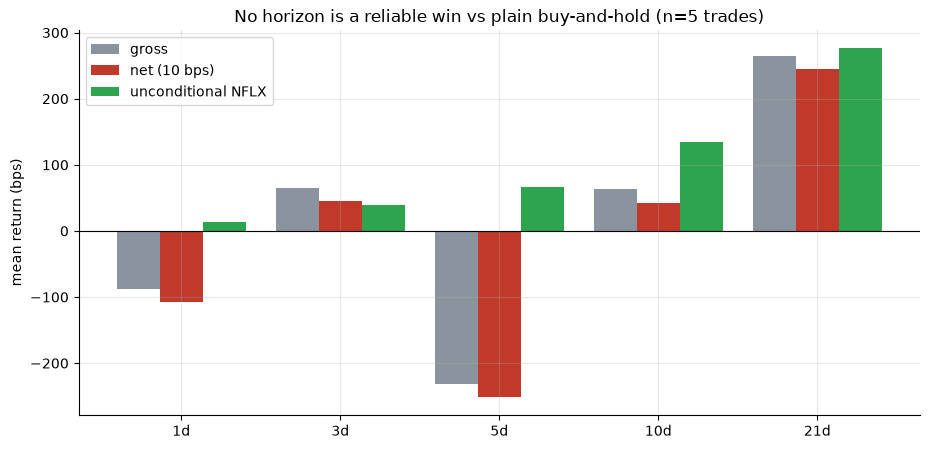

net 10bps (bps): {1: -108, 3: 45, 5: -252, 10: 43, 21: 245}
t(net): {1: -1.06, 3: 0.19, 5: -0.56, 10: 0.11, 21: 0.34}
unconditional NFLX (bps): {1: 13, 3: 40, 5: 67, 10: 134, 21: 277}


In [5]:
holds = sorted(R['timer'])
if HAVE_REAL:
    gross, net10, ts, base = [], [], [], []
    for h in holds:
        g = st.summarize_trade(st.buy_the_event(PX['NFLX'], EVENTS['date'], hold=h, cost_bps=0.0), 'ret_gross')
        n10 = st.summarize_trade(st.buy_the_event(PX['NFLX'], EVENTS['date'], hold=h, cost_bps=10.0), 'ret_net')
        gross.append(g['mean_bps']); net10.append(n10['mean_bps']); ts.append(n10['t'])
        base.append(float((PX['NFLX'].shift(-h) / PX['NFLX'] - 1.0).mean() * 1e4))
else:
    gross = [R['timer'][h][0] for h in holds]
    net10 = [R['timer'][h][1] for h in holds]
    ts = [R['timer'][h][2] for h in holds]
    base = [R['timer'][h][4] for h in holds]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
x = np.arange(len(holds)); w = 0.27
ax.bar(x - w, gross, width=w, color=GREY, label='gross')
ax.bar(x, net10, width=w, color=RED, label='net (10 bps)')
ax.bar(x + w, base, width=w, color=GREEN, label='unconditional NFLX')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('mean return (bps)')
ax.set_title('No horizon is a reliable win vs plain buy-and-hold (n=5 trades)')
ax.legend(); plt.tight_layout(); plt.show()
print('net 10bps (bps):', dict(zip(holds, [round(v) for v in net10])))
print('t(net):', dict(zip(holds, [round(t,2) for t in ts])))
print('unconditional NFLX (bps):', dict(zip(holds, [round(v) for v in base])))

> 💡 In plain words: the net buy-the-event return swings from **-108 bps** (1d) to **+245 bps** (21d) with t-stats in [-1.06, 0.34] — pure noise on five trades, and never a clean win over just holding NFLX. H₃ is not supported. **Tradability: Mirage.**

### 4e · Faithful-engine & power control — we know the truth here

Synthetic one-factor tape, **30** scheduled pseudo-events, a TUNABLE planted one-day jump. The null (edge=0) is checked over **20 seeds**; 30 events (not 5) so the small-N fat tails don't muddy the calibration read.

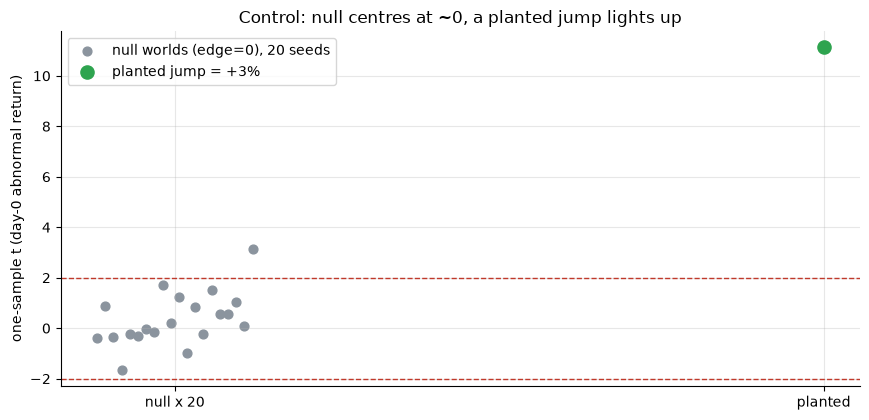

null: mean t = +0.37 (sd 1.06), |t|>=2 in 1/20  |  planted t = +11.12


In [6]:
null_ts = np.array([st.synthetic_detect(*data.synthetic_world(edge=0.0, seed=851+s))['t']
                    for s in range(20)])
a, m, e = data.synthetic_world(edge=0.03, seed=851)
planted = st.synthetic_detect(a, m, e)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40, label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted['t']], color=GREEN, s=90, zorder=5, label='planted jump = +3%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (day-0 abnormal return)')
ax.set_title('Control: null centres at ~0, a planted jump lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f"null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), "
      f"|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20  |  planted t = {planted['t']:+.2f}")

> 💡 In plain words: across 20 null worlds the detector averages t = +0.37 (sd 1.06), crossing |t|≥2 in 1/20 — well-calibrated; a planted +3% jump reads t = 11.12. The engine is unbiased and powerful *when it has the events*. The real-tape emptiness is a **sample-size** verdict, not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — cross-event mean day-0 abnormal return **-5.51%** (one-sample t = -0.66, n=5), up-days 1/5, whole-window CAR -4.01% (t = -0.38). The negative average is one 2022 crash (leave-one-out → +1.75%); the promised upside surprise is a single event (Q3'23). No robust signal, either sign.
- **Tradability `MIRAGE`** — buy-the-event never reliably beats holding NFLX; net t ∈ [-1.06, 0.34] over 1–21-day holds.
- **"The scary policy that worked?" — a business fact, not a market edge.** Subscribers grew; the tradable abnormal-return signal around the events does not exist at n=5.

## 6 · Going further

- **Power is the whole story.** Five independent events cannot support a factor claim; the deliverable is an honest anatomy. A pre-registered *portfolio* of many feared-but-successful policy events (across firms and years) is the only way to turn this into inference.
- **Dedup map:** [551-netflix-top10](../../551-netflix-top10/) (NFLX Top-10 content signal), [552-app-store-rankings](../../552-app-store-rankings/) (app-download alt-data), [299-keynote-drift](../../299-keynote-drift/) (scheduled-announcement drift) and [622-thematic-etf-curse](../../622-thematic-etf-curse/) (narrative launches) — same "does a story move a tradable price" question, all on this desk's honesty rails.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*